<a href="https://colab.research.google.com/github/karib5/CVPR-Midterm-Assignment-on-CNN/blob/main/Another_copy_of_CNN_22_48234_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries

In [1]:
# Core deep learning library
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset handling
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Utility
import zipfile
import os

This section imports all the necessary libraries required for the project.

PyTorch is used for building and training the convolutional neural network (CNN).
Torchvision is used for handling image datasets and applying transformations.

Matplotlib and Seaborn are used for visualizing performance metrics such as accuracy, loss, and confusion matrix.

Scikit-learn provides functions for evaluating the model using classification metrics like precision, recall, and F1-score.

Additional utility libraries such as zipfile and os are used for handling dataset extraction and file management.

2. Load and Explore Dataset

In [2]:
# Step 1: Unzip dataset (already uploaded in Colab)
zip_path = '/content/flowers.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Step 2: Set dataset path
data_path = '/content/flowers'

# Step 3: Basic transformation (only resize + tensor for now)
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

# Step 4: Load dataset using ImageFolder
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Step 5: Explore dataset
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))
print("Total images:", len(dataset))

# Show number of images per class
from collections import Counter
class_counts = Counter([label for _, label in dataset])

for i, class_name in enumerate(dataset.classes):
    print(f"{class_name}: {class_counts[i]} images")

Classes: ['daisy', 'rose', 'sunflower', 'tulip']
Number of classes: 4
Total images: 3265
daisy: 764 images
rose: 784 images
sunflower: 733 images
tulip: 984 images


The dataset is loaded from a ZIP file that has been uploaded to the Colab environment.
The ZIP file is extracted to the local runtime (/content) to ensure faster data access during training.

The dataset is organized into subfolders corresponding to each class (daisy, rose, sunflower, tulip),
which allows PyTorch's ImageFolder to automatically assign labels.

Basic preprocessing is applied by resizing all images to 128×128 pixels and converting them into tensors.

The dataset is then explored by printing the class names, total number of images, and the number of images per class.

3. Data Preprocessing & Augmentation

In [3]:
# Step 1: Define transformations

# Training transformation (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),   # Augmentation
    transforms.ToTensor()
])

# Validation & Test transformation (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

# Step 2: Reload dataset with transforms (important for augmentation)
full_dataset = datasets.ImageFolder(root=data_path)

# Step 3: Split dataset (70% Train, 15% Val, 15% Test)
train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

# Step 4: Apply transforms manually to subsets
train_data.dataset.transform = train_transform
val_data.dataset.transform   = test_transform
test_data.dataset.transform  = test_transform

# Step 5: Create DataLoaders (optimized)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=32, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=32, num_workers=2, pin_memory=True)

# Step 6: Verify
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 2285
Validation size: 489
Test size: 491


In this step, data preprocessing and augmentation techniques are applied to improve model performance.

The dataset is split into training (70%), validation (15%), and test (15%) sets to ensure proper evaluation.

Data augmentation is applied only to the training set using horizontal flipping to increase data diversity and reduce overfitting.

Validation and test sets are kept unchanged to provide an unbiased evaluation of the model.

DataLoaders are created with a batch size of 32, and performance is optimized using multiple workers and pinned memory for faster GPU data transfer.

4. Define CNN Architecture

In [4]:
# Model 1: Simple CNN (Baseline)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# Model 2: CNN with BatchNorm + Dropout
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

Model Summary

In [5]:
!pip install torchsummary

from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = SimpleCNN(len(dataset.classes)).to(device)
model2 = CNN(len(dataset.classes)).to(device)

print("=== Simple CNN ===")
summary(model1, (3, 128, 128))

print("\n=== CNN with BatchNorm + Dropout ===")
summary(model2, (3, 128, 128))

=== Simple CNN ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
           Flatten-7                [-1, 65536]               0
            Linear-8                  [-1, 128]       8,388,736
              ReLU-9                  [-1, 128]               0
           Linear-10                    [-1, 4]             516
Total params: 8,408,644
Trainable params: 8,408,644
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.19
Forward/backward pass size (MB): 14.00
Params siz

Two convolutional neural network (CNN) architectures are implemented for comparison.

The first model (SimpleCNN) is a baseline model consisting of convolutional, ReLU, and max-pooling layers followed by fully connected layers.

The second model includes Batch Normalization and Dropout. Batch Normalization improves training stability and convergence speed, while Dropout helps prevent overfitting by randomly disabling neurons during training.

The model summary provides a detailed view of each layer, output dimensions, and total trainable parameters.

5. Training Loop with Validation

In [6]:
def train_model(model, train_loader, val_loader, epochs=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer (Adam)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    # Store metrics
    train_acc, val_acc = [], []
    train_loss, val_loss = [], []

    for epoch in range(epochs):

        # -------- TRAINING --------
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc.append(100 * correct / total)
        train_loss.append(running_loss / len(train_loader))

        # -------- VALIDATION --------
        model.eval()
        correct, total, running_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc.append(100 * correct / total)
        val_loss.append(running_loss / len(val_loader))

        scheduler.step()

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.2f}, Val Acc={val_acc[-1]:.2f}")

    return model, train_acc, val_acc, train_loss, val_loss

Train Both Models

In [7]:
# Train SimpleCNN
print("Training SimpleCNN...")
model1, acc1, val1, loss1, vloss1 = train_model(model1, train_loader, val_loader)

# Train Advanced CNN
print("\nTraining Advanced CNN...")
model2, acc2, val2, loss2, vloss2 = train_model(model2, train_loader, val_loader)

Training SimpleCNN...
Epoch 1: Train Acc=51.60, Val Acc=60.74
Epoch 2: Train Acc=64.86, Val Acc=62.99
Epoch 3: Train Acc=72.04, Val Acc=67.08
Epoch 4: Train Acc=81.27, Val Acc=68.10
Epoch 5: Train Acc=84.77, Val Acc=69.12
Epoch 6: Train Acc=86.96, Val Acc=70.55
Epoch 7: Train Acc=89.28, Val Acc=69.12
Epoch 8: Train Acc=89.58, Val Acc=68.10
Epoch 9: Train Acc=89.63, Val Acc=67.89
Epoch 10: Train Acc=89.93, Val Acc=68.30

Training Advanced CNN...
Epoch 1: Train Acc=50.37, Val Acc=52.97
Epoch 2: Train Acc=58.69, Val Acc=61.55
Epoch 3: Train Acc=64.60, Val Acc=67.08
Epoch 4: Train Acc=72.21, Val Acc=69.94
Epoch 5: Train Acc=74.09, Val Acc=69.73
Epoch 6: Train Acc=75.05, Val Acc=70.14
Epoch 7: Train Acc=77.81, Val Acc=70.35
Epoch 8: Train Acc=77.46, Val Acc=69.94
Epoch 9: Train Acc=78.56, Val Acc=70.14
Epoch 10: Train Acc=78.82, Val Acc=70.35


In [12]:
# Save the trained model
torch.save(model2.state_dict(), "best_model.pth")
print("Model saved successfully!")

Model saved successfully!


Both models are trained using the Adam optimizer with a learning rate of 0.001.

CrossEntropyLoss is used as the loss function for multi-class classification.

A StepLR scheduler is applied to reduce the learning rate every 3 epochs, helping improve convergence and training stability.

Training and validation accuracy and loss are recorded at each epoch to analyze model performance and detect overfitting.

6. Evaluate Model on Test Set

In [8]:
# Use the better model (Advanced CNN)
model = model2
model.eval()

y_true, y_pred = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

Classification Report:

              precision    recall  f1-score   support

       daisy       0.62      0.70      0.66       105
        rose       0.56      0.52      0.54       128
   sunflower       0.82      0.85      0.83       101
       tulip       0.63      0.60      0.61       157

    accuracy                           0.65       491
   macro avg       0.66      0.67      0.66       491
weighted avg       0.65      0.65      0.65       491



The trained model is evaluated on the test dataset to measure its generalization performance.

Metrics such as precision, recall, and F1-score are computed using the classification report.

These metrics provide a detailed understanding of how well the model performs on each class.

7. Visualizations (Loss/Accuracy + Confusion Matrix)

7.1 Accuracy & Loss Curves

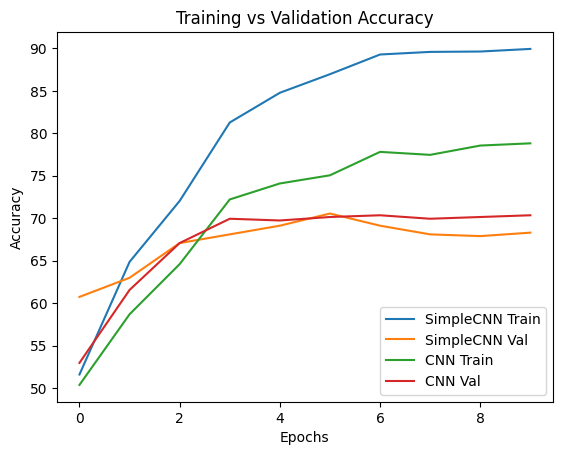

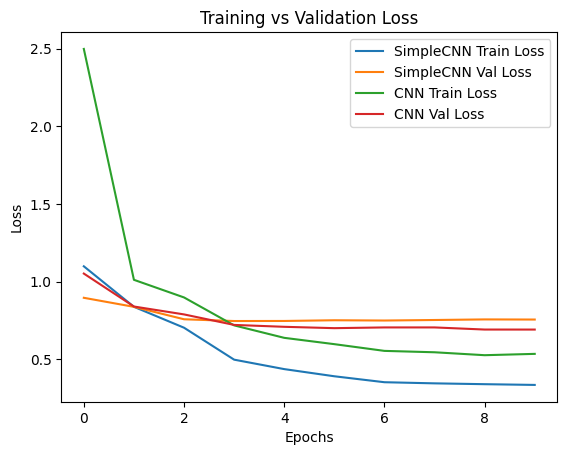

In [9]:
# Accuracy Plot

plt.figure()
plt.plot(acc1, label='SimpleCNN Train')
plt.plot(val1, label='SimpleCNN Val')

plt.plot(acc2, label='CNN Train')
plt.plot(val2, label='CNN Val')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss Plot

plt.figure()
plt.plot(loss1, label='SimpleCNN Train Loss')
plt.plot(vloss1, label='SimpleCNN Val Loss')

plt.plot(loss2, label='CNN Train Loss')
plt.plot(vloss2, label='CNN Val Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

7.2 Confusion Matrix

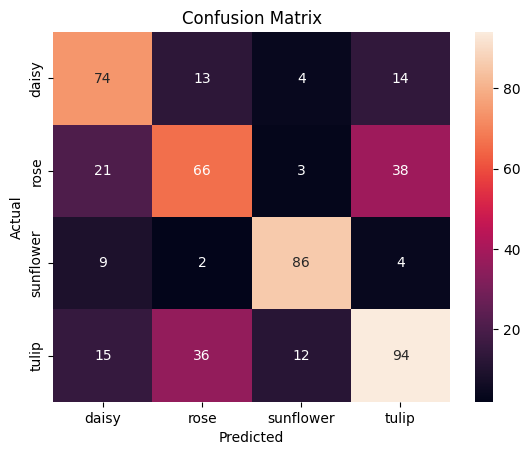

In [10]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Training and validation accuracy and loss curves are plotted to analyze the learning behavior of both models.

These graphs help identify overfitting or underfitting.

A confusion matrix is generated to visualize how well the model classifies each class and to identify common misclassifications.

8. Analysis & Discussion of Results

In [11]:
# Get detailed report as dictionary
report = classification_report(y_true, y_pred, target_names=dataset.classes, output_dict=True)

# Extract F1-scores for each class
f1_scores = {cls: report[cls]['f1-score'] for cls in dataset.classes}

# Best and worst class
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("Best Performing Class:", best_class)
print("Worst Performing Class:", worst_class)

Best Performing Class: sunflower
Worst Performing Class: rose


The performance of the models is analyzed using accuracy, loss curves, and classification metrics.

The advanced CNN model performs better than the SimpleCNN due to the use of Batch Normalization and Dropout, which improve generalization and reduce overfitting.

From the classification report, the best performing class is identified as the one with the highest F1-score, while the worst performing class has the lowest F1-score.

Misclassification may occur between visually similar classes such as different flower types, which can confuse the model.

The training and validation curves indicate whether the model is overfitting or underfitting. If validation accuracy is lower than training accuracy, it suggests slight overfitting.

9. Conclusions & Future Work

9.1 Conclusion

In this project, a convolutional neural network (CNN) was developed to classify flower images into four categories.

Two models were implemented: a SimpleCNN and an advanced CNN with Batch Normalization and Dropout. The advanced model achieved better performance due to improved regularization and training stability.

The model was successfully trained, evaluated, and analyzed using multiple performance metrics, demonstrating effective image classification capability.

9.2 Future Work

Future improvements can be made by:

- Using transfer learning with pre-trained models such as ResNet or VGG
- Applying more advanced data augmentation techniques
- Increasing dataset size for better generalization
- Tuning hyperparameters such as learning rate and batch size
- Training for more epochs with early stopping

9.3 Hyperparameters Section

Hyperparameters Used:

- Batch Size: 32  
- Learning Rate: 0.001  
- Optimizer: Adam  
- Loss Function: CrossEntropyLoss  
- Number of Epochs: 10  
- Scheduler: StepLR (step_size=3, gamma=0.1)

Rationale:

Adam optimizer is chosen for its fast convergence and adaptive learning capability.

CrossEntropyLoss is suitable for multi-class classification tasks.

Batch size of 32 provides a balance between computational efficiency and model performance.

Learning rate scheduling helps stabilize training by gradually reducing the learning rate.

In [13]:
from torchsummary import summary
summary(model2, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
       BatchNorm2d-3         [-1, 32, 128, 128]              64
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
              ReLU-6           [-1, 64, 64, 64]               0
       BatchNorm2d-7           [-1, 64, 64, 64]             128
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
             ReLU-10          [-1, 128, 32, 32]               0
      BatchNorm2d-11          [-1, 128, 32, 32]             256
        MaxPool2d-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                  [